# Plot graphs of nu/d for various alpha, d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [5]:
print(math.log(10)) # math.log is natural log
print(math.log10(100)) # math.log10 is log10

2.302585092994046
2.0


# alpha = 2
## test the relation $\ln( \nu(2,d) / d) \approx \ln(4) - \ln(\ln(d))$

In [71]:
#d = 10
max_log10_d = 6
log10_d_vals = np.arange(1,max_log10_d + 1,1)
num_values = len(log10_d_vals)
print(log10_d_vals)
this_alpha = 2.0
alpha_vals = np.zeros(num_values)
nu_vals = np.zeros(num_values)
nu_over_d_vals = np.zeros(num_values)
ln_nu_over_d_vals = np.zeros(num_values)
approx_vals = np.zeros(num_values)
diff_vals = np.zeros(num_values)

i = 0
for log10_d in log10_d_vals:
    d = 10**log10_d
    print(d)
    these_lambdas = pp.generate_pareto_draws(d, this_alpha, uniform_draws=True)
    print(d, these_lambdas.shape)
    this_nu = pp.calculate_nu(these_lambdas)
    this_nu_over_d = this_nu / d
    this_ln_nu_over_d = math.log(this_nu / d)
    this_ln_ln_d = math.log(math.log(d))
    this_approx = math.log(4.0) - this_ln_ln_d
    this_diff = this_ln_nu_over_d - this_approx
    print(this_nu, this_nu_over_d, this_ln_nu_over_d, this_approx, this_diff)
    ln_nu_over_d_vals[i] = this_ln_nu_over_d
    approx_vals[i] = this_approx
    diff_vals[i] = this_diff

    i += 1

[1 2 3 4 5 6]
10
10 (10,)
8.607269768303404 0.8607269768303404 -0.14997792492217332 0.5522619158719346 -0.702239840794108
100
100 (100,)
66.61812624728222 0.6661812624728222 -0.40619347959705254 -0.14088526468801055 -0.265308214909042
1000
1000 (1000,)
510.2370653168042 0.5102370653168042 -0.6728798273110828 -0.5463503727961749 -0.12652945451490782
10000
10000 (10000,)
4027.540145313157 0.4027540145313157 -0.9094292891750649 -0.8340324452479557 -0.07539684392710921
100000
100000 (100000,)
32932.34880418444 0.3293234880418444 -1.1107147649590159 -1.0571759965621654 -0.053538768396850456
1000000
1000000 (1000000,)
277512.5982422906 0.27751259824229063 -1.281888947754837 -1.2394975533561203 -0.04239139439871664


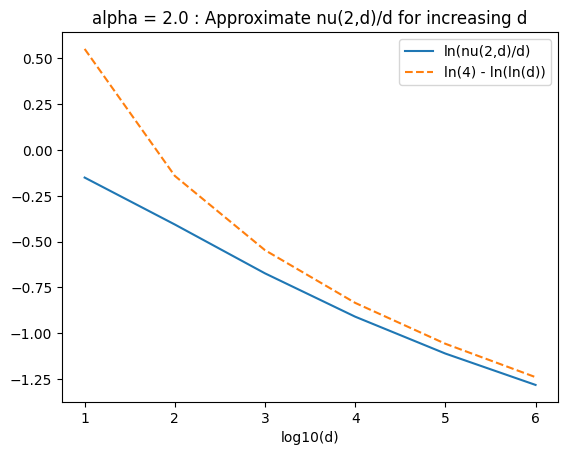

In [72]:
this_title = "alpha = 2.0 : Approximate nu(2,d)/d for increasing d"
plt.plot(log10_d_vals, ln_nu_over_d_vals, label="ln(nu(2,d)/d)")
plt.plot(log10_d_vals, approx_vals, linestyle = "--", label = "ln(4) - ln(ln(d))")
plt.xlabel("log10(d)")
plt.title(this_title)
plt.legend()
plt.savefig('ln_nu_over_d_alpha_eq_2.pdf', dpi=300, bbox_inches='tight')
plt.show()

# alpha = 1.0
## test the relation $\ln( \nu(1,d) / d) \approx 2 \ln(\ln(d)) - \ln(d)$

In [73]:
#d = 10
max_log10_d = 6
log10_d_vals = np.arange(1,max_log10_d + 1,1)
num_values = len(log10_d_vals)
print(log10_d_vals)
this_alpha = 1.0
alpha_vals = np.zeros(num_values)
nu_vals = np.zeros(num_values)
nu_over_d_vals = np.zeros(num_values)
ln_nu_over_d_vals = np.zeros(num_values)
approx_vals = np.zeros(num_values)
diff_vals = np.zeros(num_values)

i = 0
for log10_d in log10_d_vals:
    d = 10**log10_d
    print(d)
    these_lambdas = pp.generate_pareto_draws(d, this_alpha, uniform_draws=True)
    print(d, these_lambdas.shape)
    this_nu = pp.calculate_nu(these_lambdas)
    this_nu_over_d = this_nu / d
    this_ln_nu_over_d = math.log(this_nu / d)
    this_ln_d = math.log(d)
    this_ln_ln_d = math.log(math.log(d))
    this_approx = 2.0 * this_ln_ln_d - this_ln_d
    this_diff = this_ln_nu_over_d - this_approx
    print(this_nu, this_nu_over_d, this_ln_nu_over_d, this_approx, this_diff)
    ln_nu_over_d_vals[i] = this_ln_nu_over_d
    approx_vals[i] = this_approx
    diff_vals[i] = this_diff

    i += 1

[1 2 3 4 5 6]
10
10 (10,)
5.535574693051824 0.5535574693051825 -0.5913897033069755 -0.634520202498134 0.04313049919115852
100
100 (100,)
16.458196014939354 0.16458196014939352 -1.8043465948658115 -1.5508109343722896 -0.25353566049352194
1000
1000 (1000,)
34.08424832702027 0.03408424832702027 -3.3789199273071313 -3.042465811150006 -0.3364541161571255
10000
10000 (10000,)
58.241274032704744 0.005824127403270474 -5.145746092765467 -4.769686759240491 -0.3760593335249762
100000
100000 (100000,)
88.86223770573544 0.0008886223770573544 -7.025838185405742 -6.625984749606117 -0.39985343579962507
1000000
1000000 (1000000,)
125.93266545209354 0.00012593266545209353 -8.979763195029857 -8.563926729012252 -0.4158364660176055


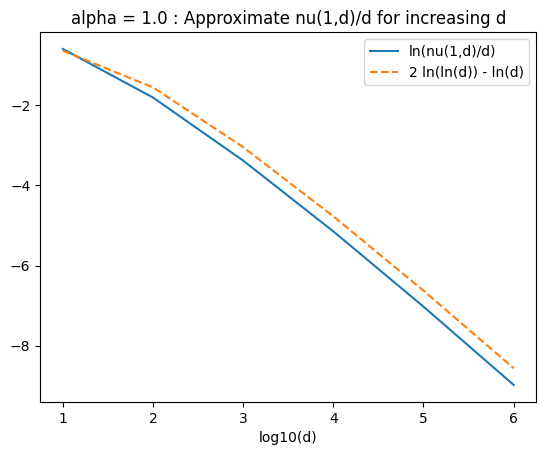

In [74]:
this_title = "alpha = 1.0 : Approximate nu(1,d)/d for increasing d"
plt.plot(log10_d_vals, ln_nu_over_d_vals, label="ln(nu(1,d)/d)")
plt.plot(log10_d_vals, approx_vals, linestyle = "--", label = "2 ln(ln(d)) - ln(d)")
plt.xlabel("log10(d)")
plt.title(this_title)
plt.legend()
plt.savefig('ln_nu_over_d_alpha_eq_1.pdf', dpi=300, bbox_inches='tight')
plt.show()

# $\alpha > 2$
## Test the approximation:
## $\ln( \nu(\alpha,d)/d - C(\alpha)) \approx \ln(C(\alpha)) - ((\alpha-2)/\alpha) \ln(d)$

In [68]:
#d = 10
this_alpha = 2.5

max_log10_d = 6
log10_d_vals = np.arange(1,max_log10_d + 1,1)
num_values = len(log10_d_vals)
print("num_values = ", num_values)
print(log10_d_vals)

#this_alpha = 2.1

rhs_vals = np.zeros(num_values)
diff_vals = np.zeros(num_values)

i = 0
for log10_d in log10_d_vals:
    d = 10**log10_d
    print(d)
    these_lambdas = pp.generate_pareto_draws(d, this_alpha, uniform_draws=True)
    print(d, these_lambdas.shape)
    this_nu = pp.calculate_nu(these_lambdas)
    this_nu_over_d = this_nu / d
    this_C_alpha = pp.C_alpha(this_alpha)
    this_lhs = math.log( this_nu_over_d - this_C_alpha)
    this_rhs = math.log(this_C_alpha) - ((this_alpha - 2)/this_alpha)* math.log(d)
    this_diff = this_lhs - this_rhs
    print(this_nu, this_nu_over_d, this_lhs, this_rhs, this_diff)
    lhs_vals[i] = this_lhs
    rhs_vals[i] = this_rhs
    diff_vals[i] = this_diff

    i += 1

num_values =  6
[1 2 3 4 5 6]
10
10 (10,)
9.107069227278133 0.9107069227278133 -1.0352111939828452 -1.048303683500928 0.01309248951808284
100
100 (100,)
79.05810286849237 0.7905810286849237 -1.4480613744172484 -1.5088207020997375 0.06075932768248915
1000
1000 (1000,)
699.9254951819862 0.6999254951819862 -1.935376248526893 -1.9693377206985465 0.03396147217165346
10000
10000 (10000,)
6430.225023722463 0.6430225023722463 -2.4364943076507153 -2.429854739297356 -0.006639568353359326
100000
100000 (100000,)
60883.67311534116 0.6088367311534116 -2.932172188469096 -2.890371757896165 -0.041800430572930924
1000000
1000000 (1000000,)
588309.9717663219 0.5883099717663219 -3.418717479861528 -3.350888776494974 -0.06782870336655389


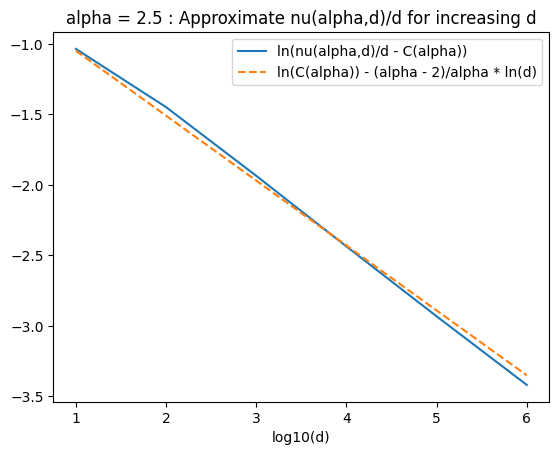

In [70]:
this_title = "alpha = " + str(this_alpha) + " : Approximate nu(alpha,d)/d for increasing d"
plt.plot(log10_d_vals, lhs_vals, label="ln(nu(alpha,d)/d - C(alpha))")
plt.plot(log10_d_vals, rhs_vals, linestyle = "--", label = "ln(C(alpha)) - (alpha - 2)/alpha * ln(d)")
plt.xlabel("log10(d)")
plt.title(this_title)
plt.legend()
plt.savefig('ln_nu_over_d_alpha_eq_2_5.pdf', dpi=300, bbox_inches='tight')
plt.show()

# $2 > \alpha > 1$
## Test the approximation:
## $\ln( \nu(\alpha,d)/d) \approx \ln(-C(\alpha)) - ((2 - \alpha)/\alpha) \ln(d)$

In [60]:
this_alpha = 1.5

max_log10_d = 6
log10_d_vals = np.arange(1,max_log10_d + 1,1)
num_values = len(log10_d_vals)
print("num_values = ", num_values)
print(log10_d_vals)

rhs_vals = np.zeros(num_values)
diff_vals = np.zeros(num_values)

i = 0
for log10_d in log10_d_vals:
    d = 10**log10_d
    print(d)
    these_lambdas = pp.generate_pareto_draws(d, this_alpha, uniform_draws=True)
    print(d, these_lambdas.shape)
    this_nu = pp.calculate_nu(these_lambdas)
    this_nu_over_d = this_nu / d
    this_C_alpha = pp.C_alpha(this_alpha)
    this_lhs = math.log(this_nu_over_d)
    this_rhs = math.log(-1.0*this_C_alpha) - ((2.0 - this_alpha)/this_alpha)* math.log(d)
    this_diff = this_lhs - this_rhs
    print(this_nu, this_nu_over_d, this_lhs, this_rhs, this_diff)
    lhs_vals[i] = this_lhs
    rhs_vals[i] = this_rhs
    diff_vals[i] = this_diff

    i += 1

num_values =  6
[1 2 3 4 5 6]
10
10 (10,)
7.616209973321827 0.7616209973321827 -0.2723062258585273 0.33108392433676115 -0.6033901501952885
100
100 (100,)
44.74718690185301 0.44747186901853014 -0.8041416057715828 -0.4364444399945875 -0.3676971657769953
1000
1000 (1000,)
230.05578506319895 0.23005578506319896 -1.4694334557148836 -1.2039728043259357 -0.2654606513889479
10000
10000 (10000,)
1117.1314349852896 0.11171314349852896 -2.1918209119821297 -1.9715011686572848 -0.22031974332484494
100000
100000 (100000,)
5292.056968981213 0.052920569689812125 -2.9389631746797176 -2.739029532988633 -0.1999336416910844
1000000
1000000 (1000000,)
24793.90868445934 0.02479390868445934 -3.6971572735422575 -3.506557897319981 -0.19059937622227663


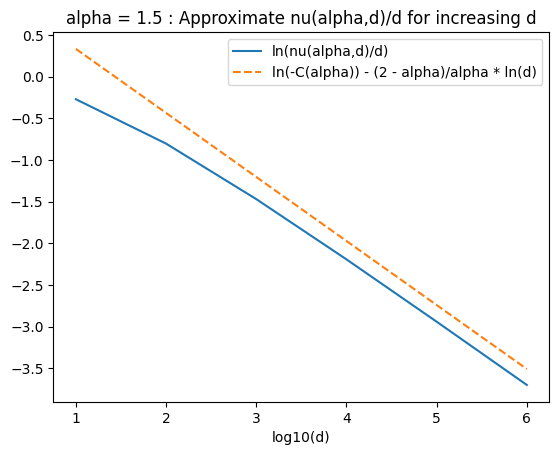

In [67]:
this_title = "alpha = " + str(this_alpha) + " : Approximate nu(alpha,d)/d for increasing d"
plt.plot(log10_d_vals, lhs_vals, label="ln(nu(alpha,d)/d)")
plt.plot(log10_d_vals, rhs_vals, linestyle = "--", label = "ln(-C(alpha)) - (2 - alpha)/alpha * ln(d)")
plt.xlabel("log10(d)")
plt.title(this_title)
plt.legend()
#plt.savefig('ln_nu_over_d_alpha_eq_1_5.pdf', dpi=300, bbox_inches='tight')
plt.show()

# $1 > \alpha$
## Test the approximation:
## $\ln(- 2 C(\alpha)) - ((1 -\alpha)/\alpha) \ln(d) \approx \ln( -C(\alpha) - \nu(\alpha,d))$

In [81]:
#d = 10
max_log10_d = 6
log10_d_vals = np.arange(1,max_log10_d + 1,1)
num_values = len(log10_d_vals)
print(log10_d_vals)
this_alpha = 0.5
alpha_vals = np.zeros(num_values)
#nu_vals = np.zeros(num_values)
#nu_over_d_vals = np.zeros(num_values)
#ln_nu_over_d_vals = np.zeros(num_values)
#approx_vals = np.zeros(num_values)
diff_vals = np.zeros(num_values)
lhs_vals = np.zeros(num_values)
rhs_vals = np.zeros(num_values)

i = 0
for log10_d in log10_d_vals:
    d = 10**log10_d
    print(d)
    these_lambdas = pp.generate_pareto_draws(d, this_alpha, uniform_draws=True)
    print(d, these_lambdas.shape)
    this_nu = pp.calculate_nu(these_lambdas)
    this_nu_over_d = this_nu / d
    #this_ln_nu_over_d = math.log(this_nu / d)
    this_neg_C_alpha = -1.0 * pp.C_alpha(this_alpha)
    this_C_alpha = pp.C_alpha(this_alpha)
    print(-1.0*this_neg_C_alpha, this_nu, (-1.0*this_neg_C_alpha) - this_nu)
    #this_rhs = math.log((-1.0*this_neg_C_alpha) - this_nu)
    #this_lhs = math.log(-2.0 * this_neg_C_alpha) - ( (1.0 - this_alpha)/this_alpha) * math.log(d)
    this_lhs = math.log(this_nu_over_d)
    this_rhs = math.log(-1.0*this_C_alpha) - ((2.0 - this_alpha)/this_alpha)* math.log(d)
    this_diff = this_lhs - this_rhs
    #this_ln_d = math.log(d)
    #this_ln_ln_d = math.log(math.log(d))
    #this_approx = 2.0 * this_ln_ln_d - this_ln_d
    this_diff = this_lhs - this_rhs
    print(this_nu, this_neg_C_alpha, this_lhs, this_rhs, this_diff)
    lhs_vals[i] = this_lhs
    rhs_vals[i] = this_rhs
    #ln_nu_over_d_vals[i] = this_ln_nu_over_d
    #approx_vals[i] = this_approx
    diff_vals[i] = this_diff

    i += 1

[1 2 3 4 5 6]
10
10 (10,)
-3.0 2.2196846735163525 -5.219684673516353
2.2196846735163525 3.0 -1.5052199461549436 -5.809142990314028 4.3039230441590846
100
100 (100,)
-3.0 2.4698473446914706 -5.469847344691471
2.4698473446914706 3.0 -3.7010138410267728 -12.716898269296166 9.015884428269393
1000
1000 (1000,)
-3.0 2.4969628075846133 -5.496962807584613
2.4969628075846133 3.0 -5.992680162635392 -19.6246535482783 13.631973385642908
10000
10000 (10000,)
-3.0 2.4996960608862953 -5.499696060886295
2.4996960608862953 3.0 -8.294171223138427 -26.53240882726044 18.238237604122013
100000
100000 (100000,)
-3.0 2.4999696038732635 -5.4999696038732635
2.4999696038732635 3.0 -10.596646891620683 -33.44016410624258 22.843517214621894
1000000
1000000 (1000000,)
-3.0 2.5000001204732962 -5.500000120473296
2.5000001204732962 3.0 -12.899219777900802 -40.34791938522471 27.44869960732391


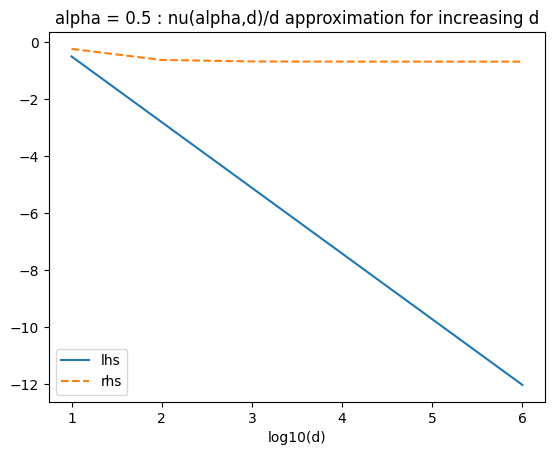

In [78]:
this_title = "alpha = " + str(this_alpha) + " : nu(alpha,d)/d approximation for increasing d"
plt.plot(log10_d_vals, lhs_vals, label="lhs")
plt.plot(log10_d_vals, rhs_vals, linestyle = "--", label = "rhs")
plt.xlabel("log10(d)")
plt.title(this_title)
plt.legend()
#plt.savefig('ln_nu_over_d_alpha_eq_0.9.pdf', dpi=300, bbox_inches='tight')
plt.show()